### kroki 1 oraz 2

In [ ]:
import pandas as pd
from google.cloud import bigquery
from google.oauth2 import service_account
import numpy as np

credentials = service_account.Credentials.from_service_account_file("key.json") # lokalizacja pobranego klucza

client = bigquery.Client(credentials=credentials, project=credentials.project_id) 

query = """
SELECT *
FROM `bigquery-public-data.noaa_gsod.gsod2020`
LIMIT 10
"""

query_job = client.query(query)
query_result = query_job.result()
df = query_result.to_dataframe()

### krok 3

In [3]:
sql_query = """
SELECT 
    obs.stn, obs.wban, obs.year, obs.mo, obs.da, obs.temp, obs.prcp, obs.max, obs.min, obs.visib,
    st.country
FROM (
    SELECT * FROM `bigquery-public-data.noaa_gsod.gsod1961`
    UNION ALL
    SELECT * FROM `bigquery-public-data.noaa_gsod.gsod1962`
) AS obs
LEFT JOIN `bigquery-public-data.noaa_gsod.stations` AS st
  ON obs.stn = st.usaf AND obs.wban = st.wban
"""

df = client.query(sql_query).to_dataframe()

print("3. Analiza struktury danych: ")
print(f"3.1. Liczba zapisanych wierszy: {len(df)}")
print(f"3.2. Liczba krajów: {df['country'].dropna().nunique()}")
print("\n3.3. Sposób zapisu dziennego dla lokalizacji:")
dzienny_podglad = (
    df.sort_values(['stn', 'wban', 'year', 'mo', 'da'])
      .groupby(['stn', 'wban'], as_index=False)
      .head(2)
      [['stn', 'wban', 'year', 'mo', 'da', 'temp', 'prcp']]
      .head(5)
)
print(dzienny_podglad)

print("\n3.4. Formaty zapisu wartości liczbowych:")
kolumny_numeryczne = df.select_dtypes(include='number').columns
print(df[kolumny_numeryczne].dtypes)

daty = pd.to_datetime(
    {
        'year': df['year'],
        'month': df['mo'],
        'day': df['da']
    }
)

temp_ok = df['temp'] < 900
prcp_ok = df['prcp'] < 90

print(f"\n3.5. Przedział czasowy: {daty.min().date()} - {daty.max().date()}")
print(f"Zakres dat dla temperatury: {daty[temp_ok].min().date()} - {daty[temp_ok].max().date()}")
print(f"Zakres dat dla opadów: {daty[prcp_ok].min().date()} - {daty[prcp_ok].max().date()}")

print("\n3.6. Dodatkowe informacje o danych pogodowych:")
print("1. Zbiór zawiera dane dobowe: rok (year), miesiąc (mo), dzień (da).")
print("2. Lokalizacja stacji jest identyfikowana przez parę: stn + wban.")
print("3. Kolumna country z tabeli stations opisuje kraj stacji.")
print("4. Temp, max i min opisują temperatury, a prcp oznacza opad dobowy.")
print("5. Kolumna visib przechowuje wartość widoczności.")
print("6. W danych NOAA braki często mają wartości zastępcze (np. 99.99, 999.9).")

3. Analiza struktury danych: 
3.1. Liczba zapisanych wierszy: 1863120
3.2. Liczba krajów: 144

3.3. Sposób zapisu dziennego dla lokalizacji:
            stn   wban  year  mo  da  temp  prcp
313450   028070  99999  1961  01  01  21.4  0.02
844487   028070  99999  1961  01  02  18.9  0.08
846322   028360  99999  1961  01  01  19.6  0.04
837529   028360  99999  1961  01  02  21.4  0.12
1594605  028640  99999  1961  01  01  22.3  0.04

3.4. Formaty zapisu wartości liczbowych:
temp     float64
prcp     float64
max      float64
min      float64
visib    float64
dtype: object

3.5. Przedział czasowy: 1961-01-01 - 1962-12-31
Zakres dat dla temperatury: 1961-01-01 - 1962-12-31
Zakres dat dla opadów: 1961-01-01 - 1962-12-31

3.6. Dodatkowe informacje o danych pogodowych:
1. Zbiór zawiera dane dobowe: rok (year), miesiąc (mo), dzień (da).
2. Lokalizacja stacji jest identyfikowana przez parę: stn + wban.
3. Kolumna country z tabeli stations opisuje kraj stacji.
4. Temp, max i min opisują temperatu

### krok 4

In [4]:
# 4.1 Lokalizacje i kraje
query_41 = """
SELECT DISTINCT s.usaf AS stn, s.wban, s.name, s.country, s.state
FROM `bigquery-public-data.noaa_gsod.stations` AS s
INNER JOIN (
    SELECT stn, wban FROM `bigquery-public-data.noaa_gsod.gsod1961`
    UNION DISTINCT
    SELECT stn, wban FROM `bigquery-public-data.noaa_gsod.gsod1962`
) AS active ON s.usaf = active.stn AND s.wban = active.wban
"""
df_41 = client.query(query_41).to_dataframe()
df_41 = df_41.replace(['99999', 99999], "brak").drop_duplicates()
df_41.to_csv('4_1_stacje.csv', index=False)

# 4.2 Warunki pogodowe dziennie
query_42 = """
SELECT stn, wban, year, mo, da, temp, dewp, slp, visib, wdsp, prcp
FROM `bigquery-public-data.noaa_gsod.gsod1961`
UNION ALL
SELECT stn, wban, year, mo, da, temp, dewp, slp, visib, wdsp, prcp
FROM `bigquery-public-data.noaa_gsod.gsod1962`
"""
df_42 = client.query(query_42).to_dataframe()
df_42['date'] = pd.to_datetime(
    df_42[['year', 'mo', 'da']].astype(str).agg('-'.join, axis=1)
)
df_42 = df_42.replace(['99999', 99999, 99.9, 99.99, 999.9, '999.9', 9999.9], "brak").drop_duplicates()
df_42.to_csv('4_2_pogoda_dzienna.csv', index=False)

# 4.3 Zjawiska ekstremalne
query_43 = """
SELECT stn, wban, year, mo, da, max, min, gust, mxpsd, sndp, hail, thunder, tornado_funnel_cloud
FROM `bigquery-public-data.noaa_gsod.gsod1961`
UNION ALL
SELECT stn, wban, year, mo, da, max, min, gust, mxpsd, sndp, hail, thunder, tornado_funnel_cloud
FROM `bigquery-public-data.noaa_gsod.gsod1962`
"""
df_43 = client.query(query_43).to_dataframe()
df_43['date'] = pd.to_datetime(
    df_43[['year', 'mo', 'da']].astype(str).agg('-'.join, axis=1)
)
df_43 = df_43.replace(['99999', 99999, 99.9, 99.99, 999.9, '999.9', 9999.9], "brak").drop_duplicates()
df_43.to_csv('4_3_ekstrema.csv', index=False)

# 4.4 Trendy czasowe
query_44 = """
SELECT stn, wban, year, mo, da, temp, prcp
FROM `bigquery-public-data.noaa_gsod.gsod1961`
UNION ALL
SELECT stn, wban, year, mo, da, temp, prcp
FROM `bigquery-public-data.noaa_gsod.gsod1962`
"""
df_44 = client.query(query_44).to_dataframe()
df_44['date'] = pd.to_datetime(
    df_44[['year', 'mo', 'da']].astype(str).agg('-'.join, axis=1)
)
df_44 = df_44.replace(['99999', 99999, 99.9, 99.99, 999.9, '999.9', 9999.9], "brak").drop_duplicates()
df_44.to_csv('4_4_trendy_czasowe.csv', index=False)

# 4.5 Analiza dni upalnych (temperatura maksymalna > 86 fahrenheit)
query_45 = """
SELECT stn, wban, year, mo, da, temp, max, min, visib
FROM `bigquery-public-data.noaa_gsod.gsod1961`
WHERE max > 86.0
UNION ALL
SELECT stn, wban, year, mo, da, temp, max, min, visib
FROM `bigquery-public-data.noaa_gsod.gsod1962`
WHERE max > 86.0
"""
df_45 = client.query(query_45).to_dataframe()
df_45['date'] = pd.to_datetime(
    df_45[['year', 'mo', 'da']].astype(str).agg('-'.join, axis=1)
)
df_45 = df_45.replace(['99999', 99999, 99.9, 99.99, 999.9, '999.9', 9999.9], "brak").drop_duplicates()
df_45.to_csv('4_5_dni_upalne.csv', index=False)

### krok 5

In [5]:
for df in [df_41, df_42, df_43, df_44, df_45]:
    df['stn'] = df['stn'].astype(str)
    df['wban'] = df['wban'].astype(str)

df_final = pd.merge(
    df_42, df_43, on=['stn', 'wban', 'date', 'year', 'mo', 'da'], how='outer')
df_final = pd.merge(df_final, df_44, on=[
                    'stn', 'wban', 'date', 'year', 'mo', 'da', 'temp', 'prcp'], how='outer')
df_final = pd.merge(df_final, df_45, on=[
                    'stn', 'wban', 'date', 'year', 'mo', 'da', 'temp', 'max', 'min', 'visib'], how='outer')
df_final = pd.merge(df_final, df_41, on=['stn', 'wban'], how='left')

df_final = df_final.drop_duplicates()

df_final.to_csv('5_finalny.csv', index=False)

### krok 6

In [6]:
df_fao = pd.read_csv('rolnictwo.csv', encoding='utf-8-sig')
df_fao.columns = df_fao.columns.str.strip()
df_final = pd.read_csv('5_finalny.csv', low_memory=False)

kolumny_pogodowe = ['temp', 'prcp', 'max', 'min', 'visib']
df_final[kolumny_pogodowe] = (
    df_final[kolumny_pogodowe]
    .replace('brak', np.nan)
    .apply(pd.to_numeric, errors='coerce')
)

df_final['year'] = pd.to_numeric(df_final['year'], errors='coerce').astype('Int64')
df_final = df_final.dropna(subset=['country', 'year'])

pogoda_roczna = df_final.groupby(['country', 'year'], as_index=False).agg({
    'temp': 'mean',
    'prcp': 'sum',
    'max': 'max',
    'min': 'min',
    'visib': 'mean'
})

mapa_krajow = {
    'AC': 'Antigua and Barbuda',
    'AE': 'United Arab Emirates',
    'AG': 'Algeria',
    'AJ': 'USSR',
    'AL': 'Albania',
    'AM': 'USSR',
    'AO': 'Angola',
    'AQ': 'Samoa',
    'AR': 'Argentina',
    'AS': 'Australia',
    'AU': 'Austria',
    'AY': 'Australia',
    'BA': 'Bahrain',
    'BD': 'United Kingdom of Great Britain and Northern Ireland',
    'BF': 'Bahamas',
    'BG': 'Bangladesh',
    'BH': 'Belize',
    'BK': 'Yugoslav SFR',
    'BL': 'Bolivia (Plurinational State of)',
    'BM': 'Myanmar',
    'BO': 'USSR',
    'BP': 'Solomon Islands',
    'BR': 'Brazil',
    'BU': 'Bulgaria',
    'CA': 'Canada',
    'CB': 'Cambodia',
    'CE': 'Sri Lanka',
    'CH': 'China, mainland',
    'CI': 'Chile',
    'CK': 'Australia',
    'CO': 'Colombia',
    'CQ': 'United States of America',
    'CU': 'Cuba',
    'CY': 'Cyprus',
    'DA': 'Denmark',
    'DJ': 'Djibouti',
    'EG': 'Egypt',
    'EN': 'USSR',
    'ER': 'Ethiopia PDR',
    'ES': 'El Salvador',
    'ET': 'Ethiopia PDR',
    'EZ': 'Czechoslovakia',
    'FI': 'Finland',
    'FJ': 'Fiji',
    'FM': 'Kiribati',
    'FR': 'France',
    'FS': 'France',
    'GG': 'USSR',
    'GI': 'United Kingdom of Great Britain and Northern Ireland',
    'GL': 'Denmark',
    'GM': 'Germany',
    'GP': 'Guadeloupe',
    'GQ': 'United States of America',
    'GR': 'Greece',
    'GT': 'Guatemala',
    'HO': 'Honduras',
    'HR': 'Yugoslav SFR',
    'HU': 'Hungary',
    'IC': 'Iceland',
    'ID': 'Indonesia',
    'IN': 'India',
    'IS': 'Israel',
    'IT': 'Italy',
    'JA': 'Japan',
    'JO': 'Jordan',
    'KE': 'Kenya',
    'KG': 'USSR',
    'KN': "Democratic People's Republic of Korea",
    'KR': 'Kiribati',
    'KS': 'Republic of Korea',
    'KU': 'Kuwait',
    'KZ': 'USSR',
    'LA': "Lao People's Democratic Republic",
    'LE': 'Lebanon',
    'LG': 'USSR',
    'LH': 'USSR',
    'LO': 'Czechoslovakia',
    'LQ': 'United States of America',
    'LY': 'Libya',
    'MB': 'Martinique',
    'MC': 'China, Macao SAR',
    'MD': 'USSR',
    'MG': 'Mongolia',
    'MJ': 'Yugoslav SFR',
    'MK': 'Yugoslav SFR',
    'ML': 'Mali',
    'MO': 'Morocco',
    'MQ': 'United States of America',
    'MR': 'Mauritania',
    'MT': 'Malta',
    'MU': 'Oman',
    'MY': 'Malaysia',
    'NG': 'Niger',
    'NL': 'Netherlands (Kingdom of the)',
    'NT': 'Netherlands (Kingdom of the)',
    'NU': 'Nicaragua',
    'NZ': 'New Zealand',
    'OD': 'Sudan (former)',
    'PE': 'Peru',
    'PK': 'Pakistan',
    'PL': 'Poland',
    'PM': 'Panama',
    'PN': 'United Kingdom of Great Britain and Northern Ireland',
    'PO': 'Portugal',
    'PS': 'Philippines',
    'RI': 'Yugoslav SFR',
    'RM': 'Kiribati',
    'RO': 'Romania',
    'RP': 'Philippines',
    'RQ': 'Puerto Rico',
    'RS': 'USSR',
    'SA': 'Saudi Arabia',
    'SE': 'Seychelles',
    'SF': 'South Africa',
    'SH': 'United Kingdom of Great Britain and Northern Ireland',
    'SI': 'Yugoslav SFR',
    'SN': 'Singapore',
    'SO': 'Somalia',
    'SP': 'Spain',
    'SU': 'Sudan (former)',
    'SV': 'Norway',
    'SY': 'Syrian Arab Republic',
    'SZ': 'Switzerland',
    'TH': 'Thailand',
    'TI': 'USSR',
    'TK': 'United Kingdom of Great Britain and Northern Ireland',
    'TS': 'Tunisia',
    'TT': 'Timor-Leste',
    'TW': 'China, Taiwan Province of',
    'TX': 'USSR',
    'TZ': 'United Republic of Tanzania',
    'UG': 'Uganda',
    'UK': 'United Kingdom of Great Britain and Northern Ireland',
    'UP': 'USSR',
    'US': 'United States of America',
    'UY': 'Uruguay',
    'UZ': 'USSR',
    'VE': 'Venezuela (Bolivarian Republic of)',
    'VM': 'Viet Nam',
    'VQ': 'United States of America',
    'WI': 'Morocco',
    'WQ': 'United States of America',
    'YM': 'Yemen',
    'ZI': 'Zimbabwe'
}

obszary_fao = set(df_fao['Area'].dropna().unique())
przefiltrowana = {}
for k, v in mapa_krajow.items():
    if v in obszary_fao:
        przefiltrowana[k] = v
mapa_krajow = przefiltrowana

pogoda_roczna['Area'] = pogoda_roczna['country'].map(mapa_krajow)
pogoda_roczna['Year'] = pd.to_numeric(pogoda_roczna['year'], errors='coerce').astype('Int64')
pogoda_roczna = pogoda_roczna.dropna(subset=['Area', 'Year'])

df_merged = pd.merge(
    df_fao,
    pogoda_roczna,
    on=['Area', 'Year'],
    how='inner'
).drop(columns=['country', 'year'], errors='ignore')

df_merged.to_csv('6_rolnictwo_pogoda.csv', index=False)

Zadanie 2

krok 1

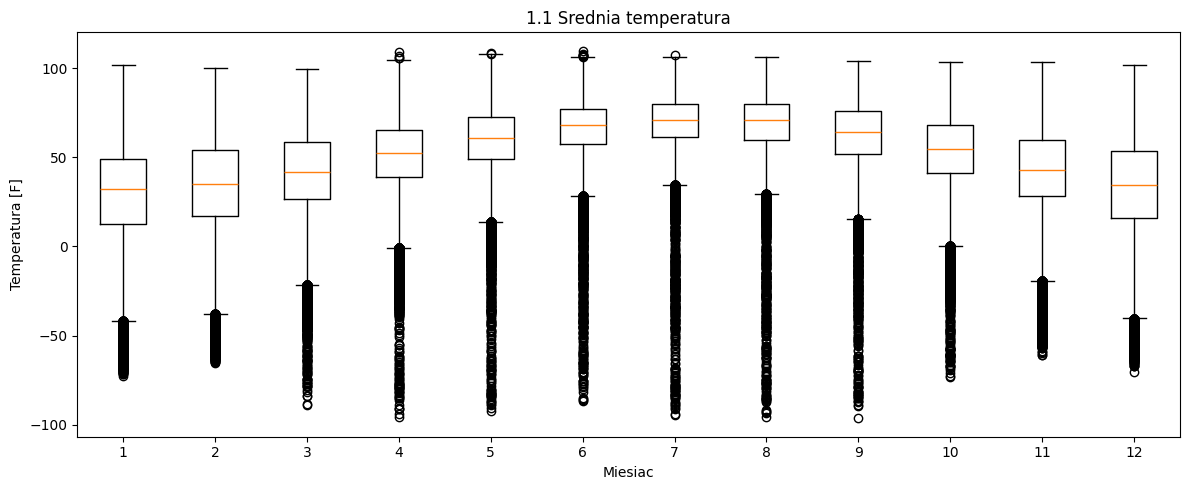

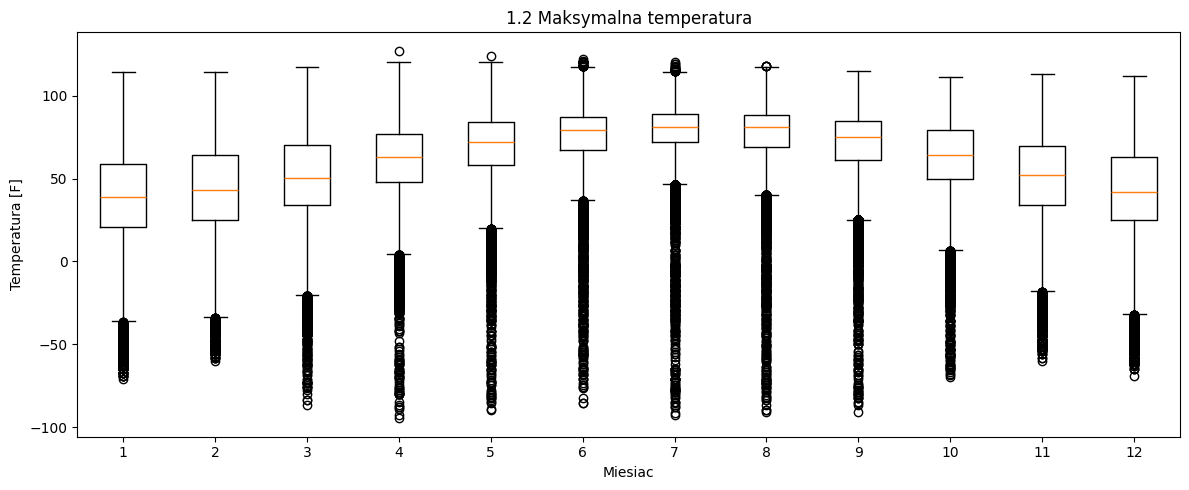

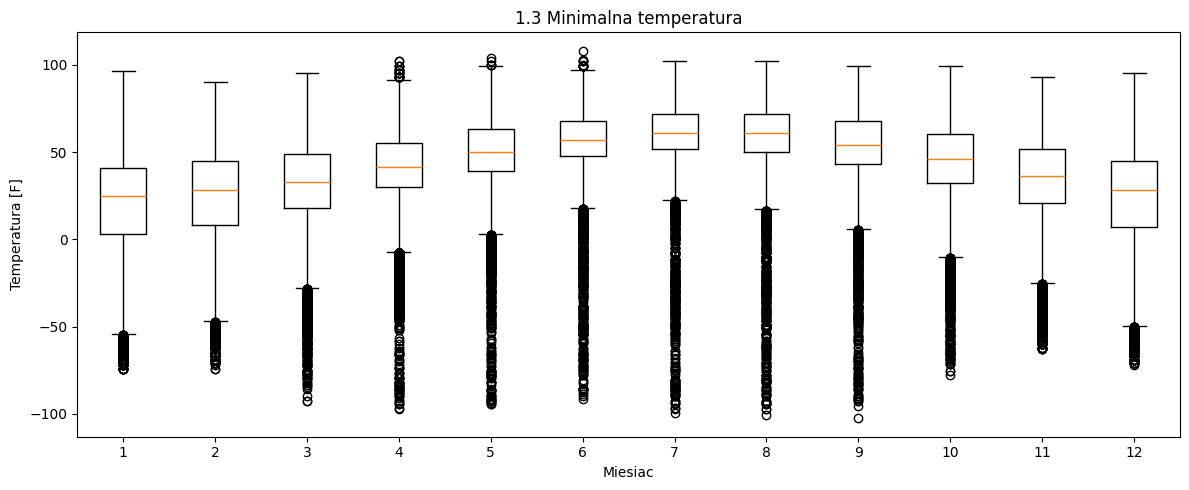

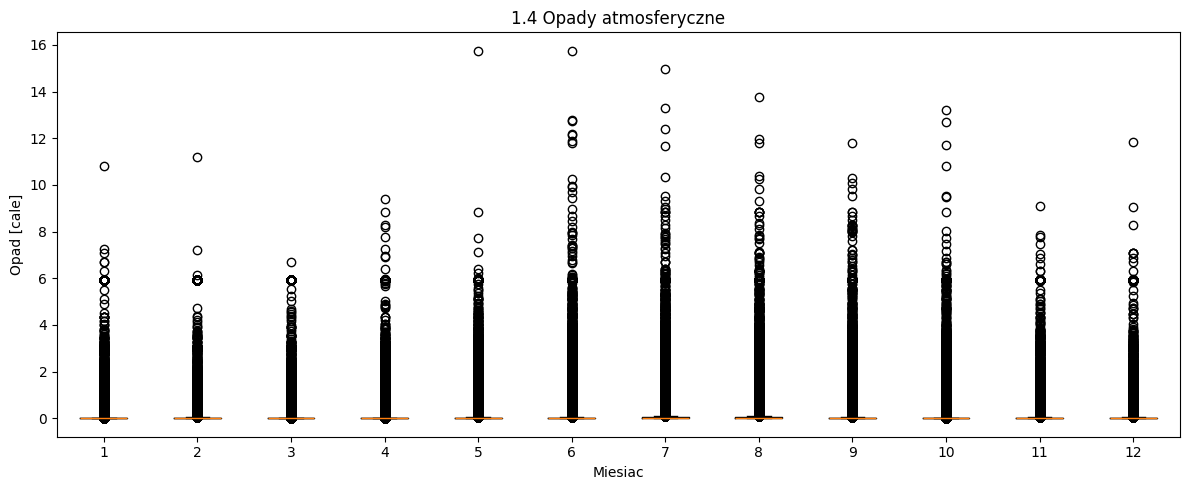

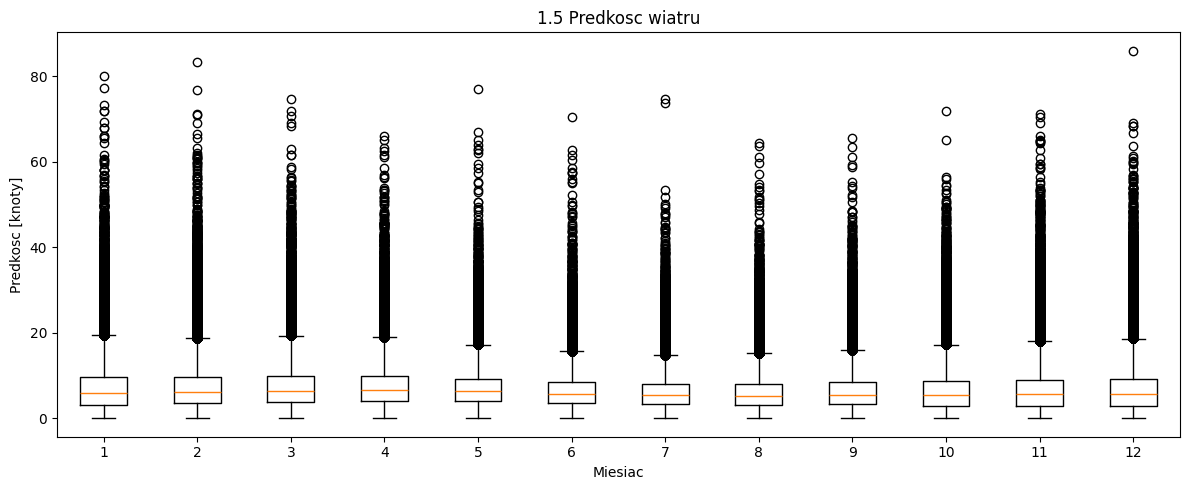

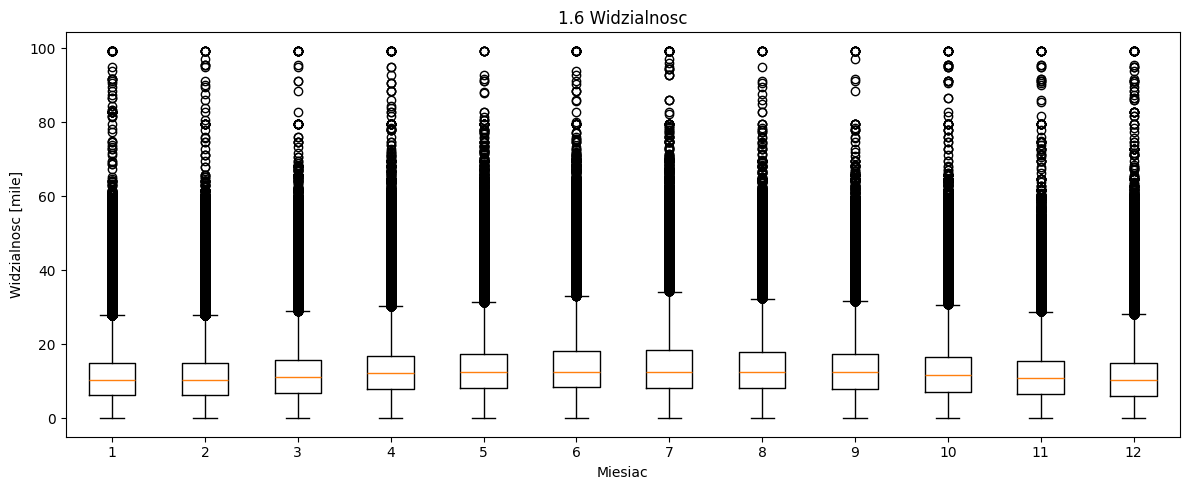

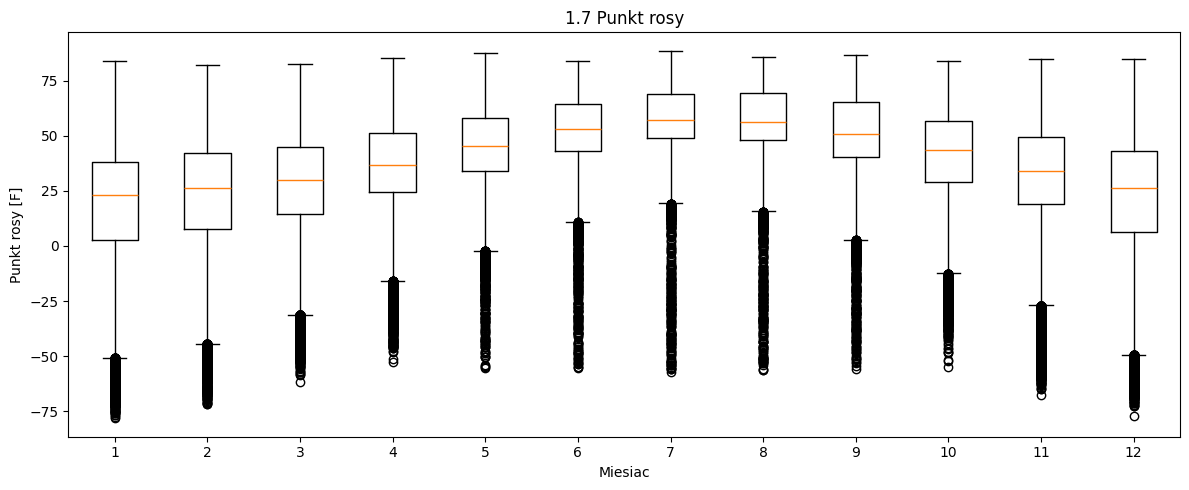

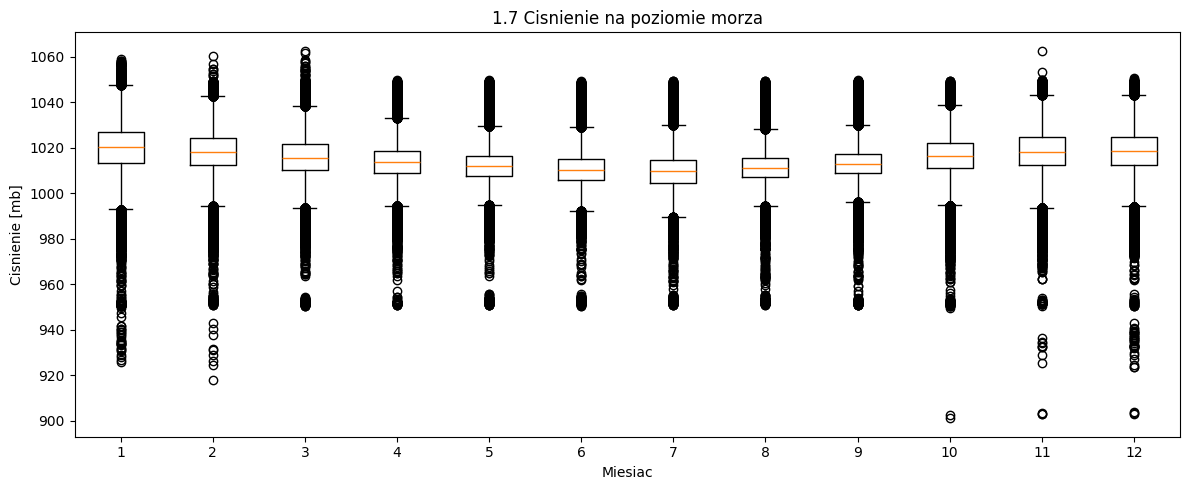

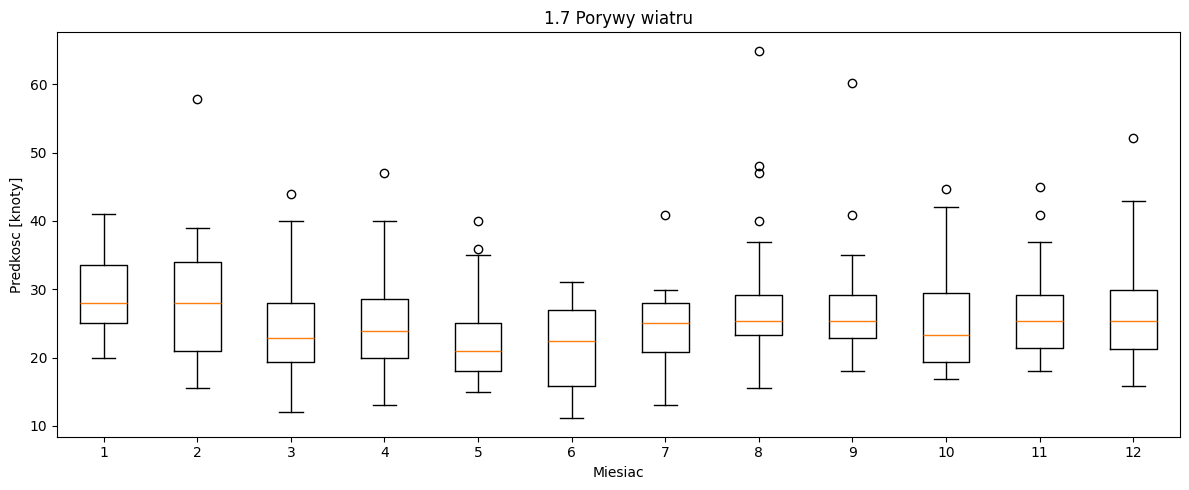

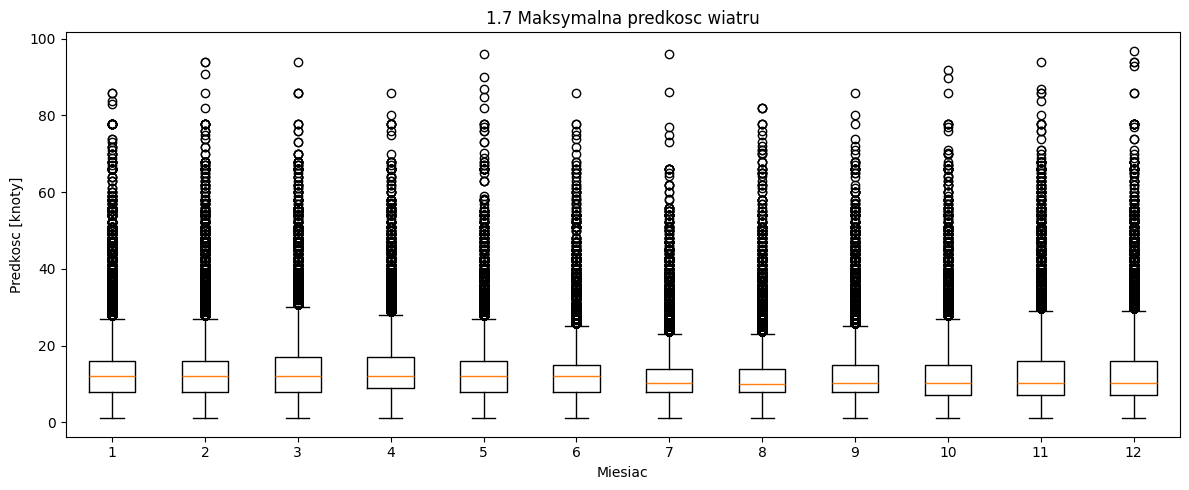

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv('5_finalny.csv', low_memory=False)

numeric_columns = ['temp', 'max', 'min', 'prcp',
                   'wdsp', 'visib', 'dewp', 'slp', 'gust', 'mxpsd']
for col in numeric_columns:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')

data['month'] = pd.to_numeric(data['mo'], errors='coerce')
months = list(range(1, 13))

metrics = [
    ('temp', '1.1 Srednia temperatura', 'Temperatura [F]'),
    ('max', '1.2 Maksymalna temperatura', 'Temperatura [F]'),
    ('min', '1.3 Minimalna temperatura', 'Temperatura [F]'),
    ('prcp', '1.4 Opady atmosferyczne', 'Opad [cale]'),
    ('wdsp', '1.5 Predkosc wiatru', 'Predkosc [knoty]'),
    ('visib', '1.6 Widzialnosc', 'Widzialnosc [mile]'),
    ('dewp', '1.7 Punkt rosy', 'Punkt rosy [F]'),
    ('slp', '1.7 Cisnienie na poziomie morza', 'Cisnienie [mb]'),
    ('gust', '1.7 Porywy wiatru', 'Predkosc [knoty]'),
    ('mxpsd', '1.7 Maksymalna predkosc wiatru', 'Predkosc [knoty]'),
]

for metric, title, y_label in metrics:
    if metric not in data.columns:
        continue

    month_data = [
        data.loc[data['month'] == m, metric].dropna().values
        for m in months
    ]
    valid = [(m, values)
             for m, values in zip(months, month_data) if len(values) > 0]
    if not valid:
        continue

    month_labels = []
    grouped_data = []

    for m, values in valid:
        month_labels.append(str(m))
        grouped_data.append(values)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.boxplot(grouped_data, tick_labels=month_labels)

    all_values = np.concatenate(grouped_data)
    y_min = np.nanmin(all_values)
    y_max = np.nanmax(all_values)
    margin = 0.05 * (y_max - y_min)

    ax.set_ylim(y_min - margin, y_max + margin)
    ax.set_title(f'{title}')
    ax.set_xlabel('Miesiac')
    ax.set_ylabel(y_label)

    plt.tight_layout()
    plt.show()

# Analiza wykresów pudełkowych #

## 1.1 Średnia temperatura powietrza ##
Mediany średniej temperatury rosną od miesięcy zimowych do letnich, a następnie spadają jesienią i zimą, co wyraźnie obrazuje sezonowość klimatu. W miesiącach przejściowych rozstrzał pomiędzy kwartałami jest zazwyczaj większy, co świadczy o wyższej zmienności i mniejszej przewidywalności warunków pogodowych w tych okresach.

## 1.2 Maksymalna temperatura ##
Rozkład temperatur maksymalnych wykazuje podobny przebieg sezonowy jak temperatura średnia, jest jednak przesunięty w stronę wyższych wartości. Najwyższe mediany oraz górne kwartyle występują latem, natomiast najniższe zimą, co wyznacza dobowe ekstrema cieplne w skali roku.

## 1.3 Minimalna temperatura ##
Temperatury minimalne najsilniej obrazują charakterystykę okresu chłodnego – zimowe mediany i dolne kwartyle są wyraźnie niskie. Latem całe rozkłady przesuwają się w górę, co potwierdza występowanie cieplejszych nocy oraz znacznie mniejsze ryzyko spadków temperatury do wartości ekstremalnie niskich.

## 1.4 Opady atmosferyczne ##
Większość obserwacji koncentruje się blisko zera, przez co „pudełka” są niskie. Liczne wartości odstające (outliers) odpowiadają dniom z intensywnymi opadami, które występują rzadziej, ale znacząco wydłużają górny „wąs” rozkładu, wskazując na epizody ulewnych deszczów lub śnieżyc.

## 1.5 Prędkość wiatru ##
Mediany prędkości wiatru są relatywnie stabilne w skali roku i nie wykazują tak silnej sezonowości jak temperatura. Liczne wartości odstające wskazują na nagłe epizody silniejszego wiatru (np. wichury), które mogą występować o każdej porze roku, niezależnie od średnich trendów miesięcznych.

## 1.6 Widzialność ##
Rozkład widzialności charakteryzuje się dużą rozpiętością, jednak mediany pomiędzy poszczególnymi miesiącami pozostają zbliżone. Sugeruje to umiarkowaną sezonowość przy jednoczesnym występowaniu częstych skrajności – od epizodów gęstej mgły po dni z bardzo dobrą przejrzystością powietrza.

## 1.7 Dodatkowe zmienne (dewp, slp, gust, mxpsd) ##
Punkt rosy (dewp): Rośnie w miesiącach letnich, co wskazuje na wyższą zawartość wilgoci w ciepłym powietrzu.

Ciśnienie atmosferyczne (slp): Wykazuje mniejszą dynamikę zmian sezonowych niż temperatura, choć charakteryzuje się dużą dynamiką zmian w krótkich odstępach czasu

Porywy i maksymalna prędkość wiatru (gust, mxpsd): Często wykazują gwałtowne skoki i liczne wartości skrajne, co pozwala zidentyfikować okresy występowania zjawisk ekstremalnych.

Część 2

In [8]:
df_iqr = pd.read_csv('5_finalny.csv', low_memory=False).copy()

for col in ['temp', 'prcp']:
    df_iqr[col] = pd.to_numeric(df_iqr[col], errors='coerce')


def iqr_summary(series: pd.Series, name: str) -> dict:
    s = series.dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1  # zakres międzykwartylowy
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr  # wartości odstające

    outlier_mask = (series < lower) | (series > upper)
    outlier_count = int(outlier_mask.sum())
    total_non_null = int(series.notna().sum())
    outlier_pct = (outlier_count / total_non_null *
                   100) if total_non_null else 0.0

    return {
        'zmienna': name,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'dolna_granica': lower,
        'gorna_granica': upper,
        'liczba_niepustych': total_non_null,
        'liczba_outlierow_IQR': outlier_count,
        'odsetek_outlierow_%': outlier_pct,
        'maska_outlierow': outlier_mask,
    }


temp_res = iqr_summary(df_iqr['temp'], 'temp')
prcp_res = iqr_summary(df_iqr['prcp'], 'prcp')

summary = pd.DataFrame([
    {k: v for k, v in temp_res.items() if k != 'maska_outlierow'},
    {k: v for k, v in prcp_res.items() if k != 'maska_outlierow'},
])

print('Podsumowanie IQR dla temperatury i opadów:')
display(summary)

print('\nPrzykłady outlierów IQR')
print('temp:')
display(df_iqr.loc[temp_res['maska_outlierow'], [
        'stn', 'wban', 'year', 'mo', 'da', 'temp']].head(10))

print('prcp:')
display(df_iqr.loc[prcp_res['maska_outlierow'], [
        'stn', 'wban', 'year', 'mo', 'da', 'prcp']].head(10))

print('1. Outliery IQR dla temp i prcp zostawiamy w zbiorze (realne ekstrema pogodowe)')
print('2. Nie usuwamy całych wierszy, aby nie tracić informacji')

Podsumowanie IQR dla temperatury i opadów:


,zmienna,Q1,Q3,IQR,dolna_granica,gorna_granica,liczba_niepustych,liczba_outlierow_IQR,odsetek_outlierow_%
0,temp,36.4,71.80,35.40,-16.70,124.90,1863118,36500,1.959081
1,prcp,0.0,0.02,0.02,-0.03,0.05,1579367,265337,16.800212



Przykłady outlierów IQR
temp:


,stn,wban,year,mo,da,temp
33,28070,brak,1961,2,4,-22.1
34,28070,brak,1961,2,5,-17.1
35,28070,brak,1961,2,6,-30.3
356,28070,brak,1961,12,26,-20.4
383,28070,brak,1962,1,22,-25.3
384,28070,brak,1962,1,23,-32.1
385,28070,brak,1962,1,24,-29.1
387,28070,brak,1962,1,26,-26.3
408,28070,brak,1962,2,16,-21.4
409,28070,brak,1962,2,17,-19.5


prcp:


,stn,wban,year,mo,da,prcp
1,28070,brak,1961,1,2,0.08
2,28070,brak,1961,1,3,0.09
5,28070,brak,1961,1,6,0.08
11,28070,brak,1961,1,13,0.06
12,28070,brak,1961,1,14,0.20
13,28070,brak,1961,1,15,0.12
23,28070,brak,1961,1,25,0.10
36,28070,brak,1961,2,7,0.12
37,28070,brak,1961,2,8,0.16
41,28070,brak,1961,2,12,0.56


1. Outliery IQR dla temp i prcp zostawiamy w zbiorze (realne ekstrema pogodowe)
2. Nie usuwamy całych wierszy, aby nie tracić informacji


Cześć 3

In [9]:
df = pd.read_csv('5_finalny.csv', low_memory=False)

cols = ['temp', 'prcp', 'max', 'min', 'visib',
        'dewp', 'slp', 'wdsp', 'gust', 'mxpsd']
for c in cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')
        df[c] = df[c].replace(
            ['brak', '99.9', '99.99', '999.9', '9999.9', 99.9, 99.99, 999.9, 9999.9], np.nan)

# 3.1 liczba i procent brakow
braki = pd.DataFrame({
    'liczba_brakow': df.isna().sum(),
    'procent_brakow': (df.isna().sum() / len(df) * 100).round(2)
})
print('3.1 Braki danych:')
display(braki[braki['liczba_brakow'] > 0].sort_values(
    'procent_brakow', ascending=False))

# 3.3 imputacja 2 zmiennych: temp, prcp
v = ['temp', 'prcp']
mean_df = df.copy()
median_df = df.copy()
time_df = df.copy()

mean_df[v] = mean_df[v].fillna(mean_df[v].mean())
median_df[v] = median_df[v].fillna(median_df[v].median())

time_df['date'] = pd.to_datetime(
    {'year': time_df['year'], 'month': time_df['mo'], 'day': time_df['da']}, errors='coerce')
time_df = time_df.sort_values('date').set_index('date')
time_df[v] = time_df[v].interpolate(method='time', limit_direction='both')
time_df = time_df.reset_index()

porownanie = []
for col in v:
    porownanie.append({
        'zmienna': col,
        'braki_przed': int(df[col].isna().sum()),
        'braki_po_srednia': int(mean_df[col].isna().sum()),
        'braki_po_mediana': int(median_df[col].isna().sum()),
        'braki_po_interpolacja': int(time_df[col].isna().sum())
    })

print('\n3.4 Porownanie metod:')
display(pd.DataFrame(porownanie))

for col in v:
    idx = df.index[df[col].isna()][:20]
    print(f'\nPrzyklady uzupelnien dla {col}:')
    display(pd.DataFrame({
        'index': idx,
        'srednia': mean_df.loc[idx, col].values,
        'mediana': median_df.loc[idx, col].values,
        'interpolacja_czasowa': time_df.loc[idx, col].values
    }))

print('\nWybrana metoda: interpolacja czasowa')
print('Uzasadnienie: dane sa dzienne, a interpolacja daje płynne, realistyczne przejścia między dniami,')
print('podczas gdy średnia/mediana wstawiaja jedna stałą wartość i upraszczają dane')

3.1 Braki danych:


,liczba_brakow,procent_brakow
gust,1862639,99.97
state,1438317,77.20
prcp,283753,15.23
slp,251485,13.50
visib,100968,5.42
dewp,57004,3.06
mxpsd,32803,1.76
wdsp,5705,0.31
country,3998,0.21
name,3285,0.18



3.4 Porownanie metod:


,zmienna,braki_przed,braki_po_srednia,braki_po_mediana,braki_po_interpolacja
0,temp,2,0,0,0
1,prcp,283753,0,0,0



Przyklady uzupelnien dla temp:


,index,srednia,mediana,interpolacja_czasowa
0,606116,51.365962,55.6,63.4
1,1716726,51.365962,55.6,63.6



Przyklady uzupelnien dla prcp:


,index,srednia,mediana,interpolacja_czasowa
0,8,0.122338,0.0,0.10
1,19,0.122338,0.0,0.00
2,32,0.122338,0.0,0.00
3,87,0.122338,0.0,0.00
4,110,0.122338,0.0,0.00
5,118,0.122338,0.0,0.63
6,132,0.122338,0.0,0.00
7,172,0.122338,0.0,0.00
8,174,0.122338,0.0,0.00
9,191,0.122338,0.0,0.00



Wybrana metoda: interpolacja czasowa
Uzasadnienie: dane sa dzienne, a interpolacja daje płynne, realistyczne przejścia między dniami,
podczas gdy średnia/mediana wstawiaja jedna stałą wartość i upraszczają dane
